In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sympy as smp
from scipy.stats import bernoulli
import pandas as pd
import math
import pylatexenc
from IPython.display import display, Math
from qc_module import steady_state_linear_oqw, erf_approximation, S_G, S_corrected, Prob, S_entropy, t_start, t_end, mean_energy
from scipy.special import erf

C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\1854162084.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=13)


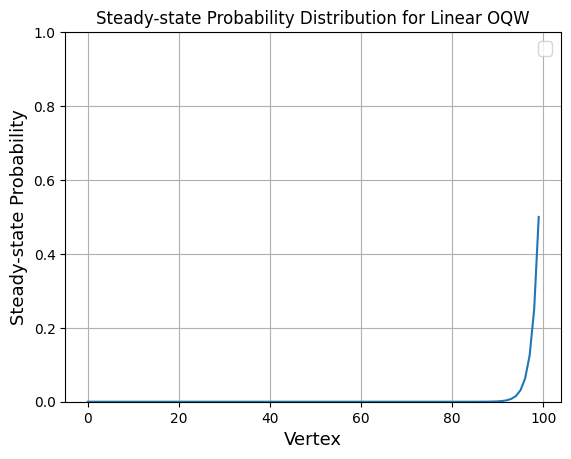

In [2]:
omega = 2/3
N = 100

list = range(N)

plt.plot(list,steady_state_linear_oqw(omega,N)   )
plt.xlabel('Vertex', fontsize=13)
plt.ylabel('Steady-state Probability', fontsize=13)
plt.title('Steady-state Probability Distribution for Linear OQW')
plt.legend(fontsize=13)
plt.grid(True)
plt.ylim(0, 1)
plt.show()

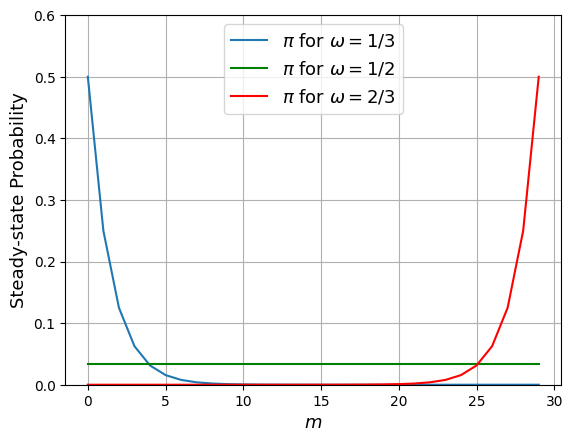

In [3]:
omega1 = 1/3
omega2 = 1/2
omega3 = 2/3
N = 30

list = range(N)

plt.plot(list,steady_state_linear_oqw(omega1,N), label=r"$\pi$ for $\omega = 1/3$"   )
plt.plot(list,steady_state_linear_oqw(omega2,N), color = 'green', label=r"$\pi$ for $\omega = 1/2$"   )
plt.plot(list,steady_state_linear_oqw(omega3,N), color = 'red', label=r"$\pi$ for $\omega = 2/3$"   )

plt.xlabel('$m$', fontsize=13)
plt.ylabel('Steady-state Probability', fontsize=13)
plt.legend(fontsize=13)
plt.grid(True)
plt.ylim(0, 0.6)

plt.savefig("steady_state_omega.pgf")


plt.show()

In [4]:
# Define omega avoiding 0 and 1 to prevent division by zero
omega = np.linspace(0.01, 0.99, 1000)

# Define lambda = 1 - omega
lmbd = 1 - omega

# Compute T
T = -1 / (np.log(omega / lmbd))

<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\611653130.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$T(\omega)$', fontsize=13)


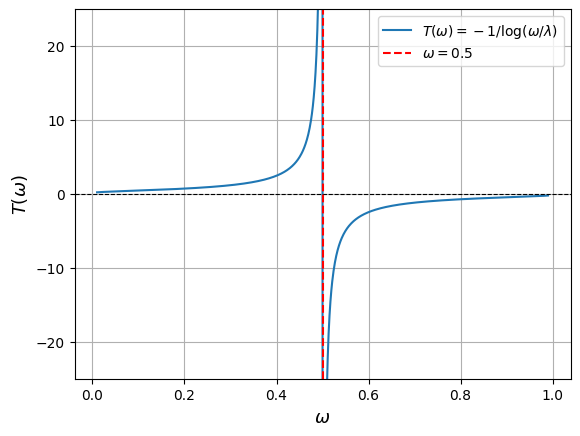

In [5]:
# Plot
plt.plot(omega, T, label=r"$T(\omega) = -1/\log(\omega/\lambda)$")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0.5, color='red', linestyle='--', label=r'$\omega = 0.5$')
plt.xlabel(r'$\omega$', fontsize=13)
plt.ylabel('$T(\omega)$', fontsize=13)
plt.legend()
plt.grid(True)
plt.ylim(-25, 25)
plt.savefig("temperature_vs_omega.pgf")

plt.show()


In [6]:
# Plot
beta = np.linspace(-100, 100, 1000)
T_b = 1/beta

plt.plot(beta, T_b, label=r"$T(\beta) = 1/\beta$")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.axvline(0.5, color='red', linestyle='--', label=r'$\beta = 0$')
plt.xlabel(r'$\beta$', fontsize=13)
plt.ylabel('$T(\beta)$', fontsize=13)
plt.legend(fontsize=13)
plt.grid(True)
plt.ylim(-1, 1)
plt.show()

plt.savefig("temperature_vs_beta.pgf")


ValueError: 
$T(eta)$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 640x480 with 1 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
def probs_p(beta: float, N: int) -> np.ndarray:
    """
    Return p_i for given beta and N using stable formulas.
    Handles beta ~ 0 (a ~ 1) by taking the uniform limit.
    """
    if np.isclose(beta, 0.0, atol=1e-12):
        p = np.full(N, 1.0 / N, dtype=float)
    else:
        # a = exp(-beta); use expm1 to avoid catastrophic cancellation
        # 1 - a     = -expm1(-beta)
        # 1 - a^N   = -expm1(-beta*N)
        i = np.arange(N, dtype=float)
        ai = np.exp(-beta * i)
        numer_const = -np.expm1(-beta)         # = 1 - a
        denom = -np.expm1(-beta * N)           # = 1 - a^N
        p = (numer_const * ai) / denom
    # Defensive normalization
    p /= p.sum()
    return p


In [8]:
def entropy_S(beta: np.ndarray, N: int) -> np.ndarray:
    """
    Compute S(beta) = -sum p_i log p_i for an array of betas.
    """
    beta = np.atleast_1d(beta).astype(float)
    S = np.empty_like(beta, dtype=float)
    for k, b in enumerate(beta):
        p = probs_p(b, N)
        # clip to avoid log(0)
        p = np.clip(p, 1e-300, 1.0)
        S[k] = -np.sum(p * np.log(p))
    return S if S.size > 1 else S.item()


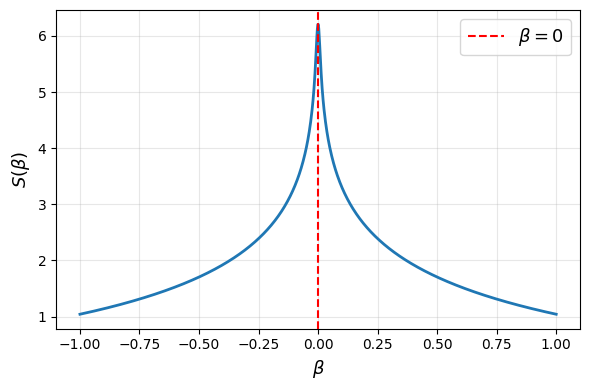

In [9]:
# Parameters
betas = np.linspace(-1, 1, 1000)
N = 500
# Compute
S_vals = entropy_S(betas, N)

plt.figure(figsize=(6, 4))
plt.plot(betas, S_vals, linewidth=2)
plt.xlabel(r"$\beta$", fontsize=13)
plt.ylabel(r"$S(\beta)$",fontsize=13)
plt.axvline(0, color='red', linestyle='--', label=r'$\beta = 0$')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig("S_beta_plot.pgf")

plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\2273489621.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=13)


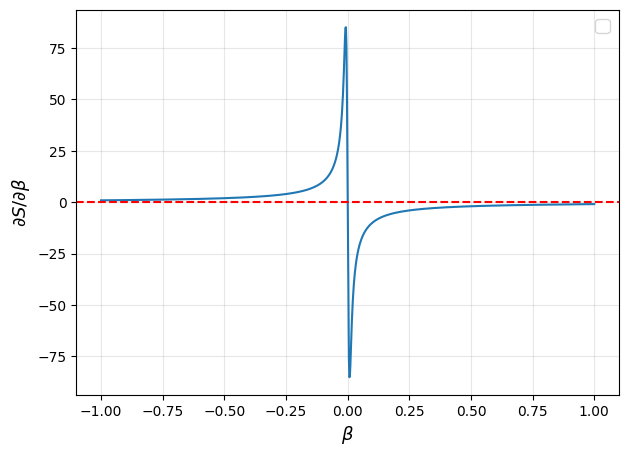

In [10]:
dS_dbeta = np.gradient(S_vals,  betas)
plt.figure(figsize=(7,5))
plt.plot(betas, dS_dbeta)
plt.xlabel(r"$\beta$", fontsize=13)
plt.ylabel(r"$\partial S / \partial \beta $", fontsize=13)
plt.axhline(0, color='red', linestyle='--')

plt.legend(fontsize=13)
plt.grid(True, alpha=0.3)
plt.savefig("S_derivative_beta_plot.pgf")

plt.show()


In [11]:
def probs_p_from_T(T: float, N: int) -> np.ndarray:
    """
    Return p_i for given T and N.
    Uses beta = 1/T, handles T→∞ (beta→0) as uniform distribution.
    """
    if np.isclose(T, np.inf) or np.isclose(1.0/T, 0.0, atol=1e-12):
        return np.full(N, 1.0/N)
    
    beta = 1.0 / T
    if np.isclose(beta, 0.0, atol=1e-12):
        p = np.full(N, 1.0 / N)
    else:
        i = np.arange(N, dtype=float)
        ai = np.exp(-beta * i)
        numer_const = -np.expm1(-beta)       # 1 - a
        denom = -np.expm1(-beta * N)         # 1 - a^N
        p = (numer_const * ai) / denom
    p /= p.sum()
    return p

def entropy_S_T(T: np.ndarray, N: int) -> np.ndarray:
    """
    Compute S(T) for array of T values.
    """
    T = np.atleast_1d(T).astype(float)
    S = np.empty_like(T, dtype=float)
    for k, temp in enumerate(T):
        p = probs_p_from_T(temp, N)
        p = np.clip(p, 1e-300, 1.0)
        S[k] = -np.sum(p * np.log(p))
    return S if S.size > 1 else S.item()


C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\3909761569.py:14: RuntimeWarning: overflow encountered in exp
  ai = np.exp(-beta * i)
C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\3909761569.py:16: RuntimeWarning: overflow encountered in expm1
  denom = -np.expm1(-beta * N)         # 1 - a^N
C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\3909761569.py:17: RuntimeWarning: overflow encountered in multiply
  p = (numer_const * ai) / denom
C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\3909761569.py:17: RuntimeWarning: invalid value encountered in divide
  p = (numer_const * ai) / denom


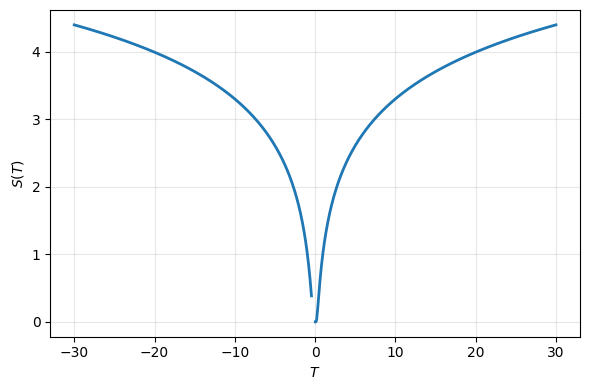

In [12]:
N = 300
T_vals = np.linspace(-30, 30, 1000)

S_vals_T = entropy_S_T(T_vals, N)

# Plot
plt.figure(figsize=(6,4))
plt.plot(T_vals, S_vals_T, linewidth=2)
plt.xlabel(r"$T$")
plt.ylabel(r"$S(T)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("S_T_plot.pgf")
plt.show()


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\3414814579.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\langle E \\rangle (\omega)$', fontsize=13)


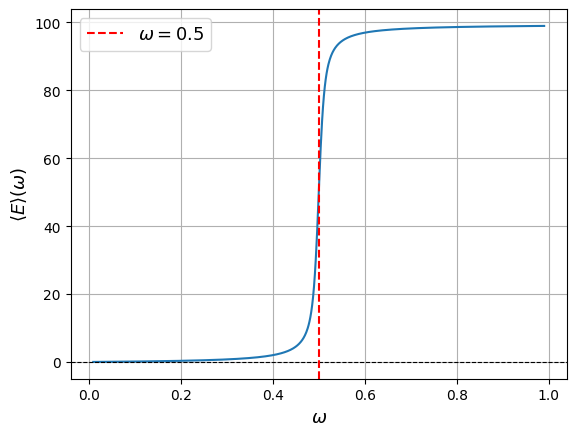

In [13]:
#plot of mean energy
N = 100
epsilon = 1

omega_values = np.linspace(0.01, 0.99, 1000)
energy_values = mean_energy(N, omega_values, epsilon)

plt.plot(omega_values, energy_values)
plt.xlabel(r'$\omega$',fontsize=13)
plt.ylabel('$\langle E \\rangle (\omega)$', fontsize=13) 
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0.5, color='red', linestyle='--', label=r'$\omega = 0.5$')
plt.legend(fontsize=13)
plt.grid(True)
plt.savefig("mean_energy_vs_omega.pgf")
plt.show()



C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\394529340.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


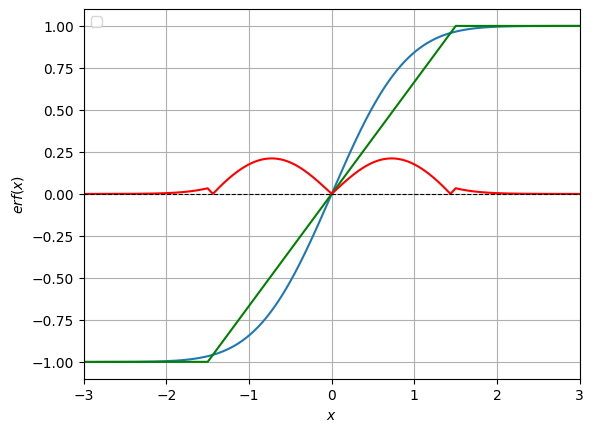

<Figure size 640x480 with 0 Axes>

In [14]:
# Erf_approx plot
x_values = np.linspace(-10, 10, 10000)
erf_values_approx = erf_approximation(x_values)
erf_values = erf(x_values)

error = abs(erf_values-erf_values_approx)

plt.plot(x_values, erf_values)
plt.plot(x_values,erf_values_approx, color = 'green')
plt.plot(x_values,error, color = 'red')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.xlabel(r'$x$')
plt.ylabel('$erf(x)$')
plt.legend()
plt.grid(True)
plt.xlim(-3,3)
plt.show()

plt.savefig("erf_approximation.pgf")

C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\625192767.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


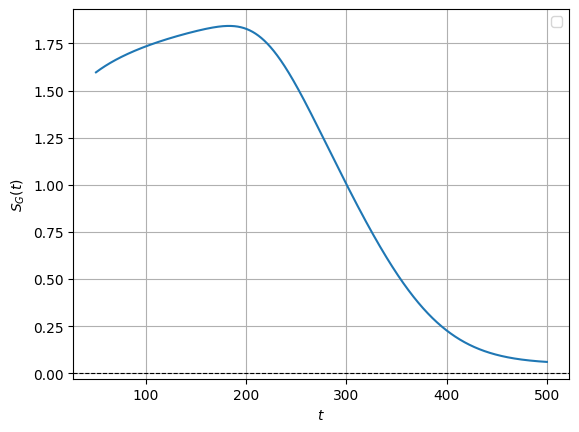

In [15]:
#Entropy of gaussian part of OQW
t_values = np.linspace(50, 500, 10000)
S_G_values = S_G(100,2/3,t_values)

plt.plot(t_values, S_G_values)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.xlabel(r'$t$')
plt.ylabel('$S_G(t)$')
plt.legend()
plt.grid(True)
plt.show()



In [16]:
S_entropy(100,2/3,500)

np.float64(1.3879373885890778)

C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\2690761166.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


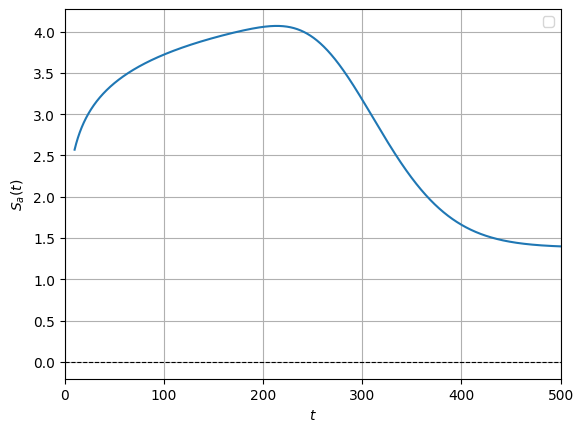

<Figure size 640x480 with 0 Axes>

In [17]:
#Analytic Entropy of OQW
t_values = np.linspace(10, 550, 10000)
S_values = S_corrected(100,2/3,t_values)

plt.plot(t_values, S_values)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.xlabel(r'$t$')
plt.ylabel('$S_a(t)$')
plt.legend()
plt.grid(True)
plt.xlim(0,500)
plt.show()

plt.savefig("analytic_oqw_entropy.pgf")

C:\Users\pedro\AppData\Local\Temp\ipykernel_20424\2192989310.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=13)


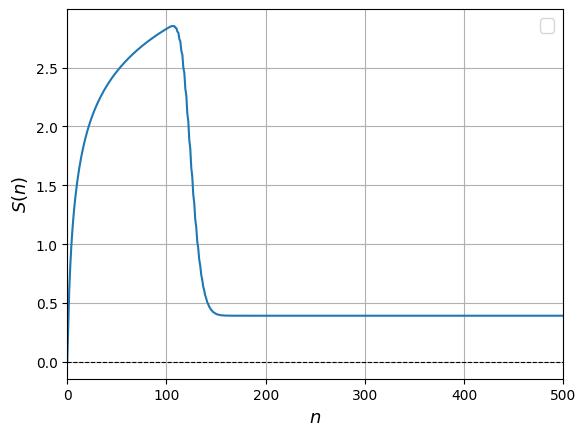

In [18]:
#Entropy of OQW
tmax = 500
N = 100
omega = 9/10


t_values = [0]*tmax
for i in range(tmax):
    t_values[i] = i

S_values = []
for t in range(len(t_values)):
    S_values.append(S_entropy(N,omega,t))


plt.plot(t_values, S_values)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.xlabel(r'$n$', fontsize=13)
plt.ylabel('$S(n)$', fontsize=13)
plt.legend(fontsize=13)
plt.grid(True)
plt.xlim(0,500)
plt.savefig("oqw_entropy.pgf")

plt.show()


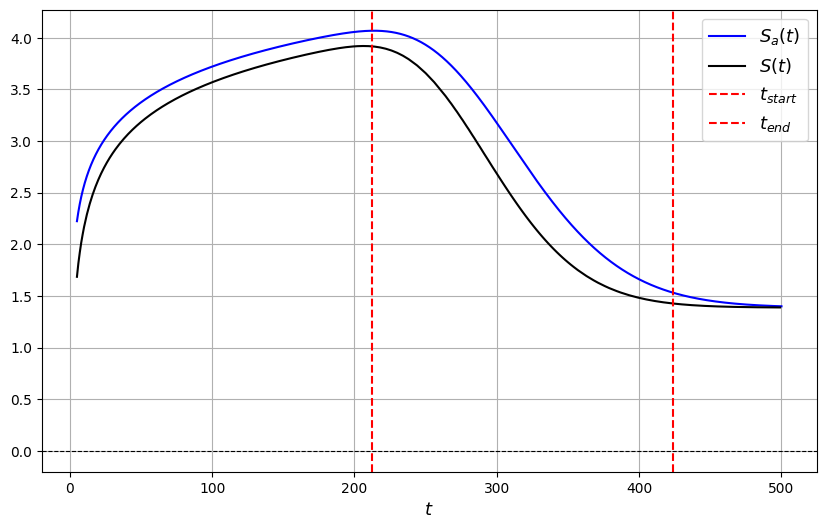

In [38]:
#Analytic Entropy of OQW
N = 100
omega = 2/3
tmax = 500


t_values_1 = np.linspace(5, tmax, 10000)
S_values_1 = S_corrected(N,omega,t_values_1)

t_values_2 = [0]*tmax

for i in range(tmax):
    t_values_2[i] = i

S_values_2 = []
for t in range(len(t_values_2)):
    S_values_2.append(S_entropy(N,omega,t))


t_values_3 = [0]*(tmax-5)
for i in range(tmax-5):
    t_values_3[i] = i

error = []
for t in range(5,len(t_values_2)):
    error.append(abs(S_values_2[t] - S_corrected(N,omega,t)))

plt.figure(figsize=(10, 6))


plt.plot(t_values_1, S_values_1, color = 'blue', label = '$S_{a}(t)$')
plt.plot(t_values_2[5:], S_values_2[5:], color = 'black', label = '$S(t)$')

tstart = t_start(N,omega)
tend = t_end(N,omega)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    

plt.axvline(tstart, color='red', linestyle='--', label=r'$t_{start}$')
plt.axvline(tend, color='red', linestyle='--', label=r'$t_{end}$')

plt.xlabel(r'$t$', fontsize=13)
plt.legend(fontsize=13)
plt.grid(True)
plt.savefig("comparison_oqw_entropy.pgf")
plt.show()

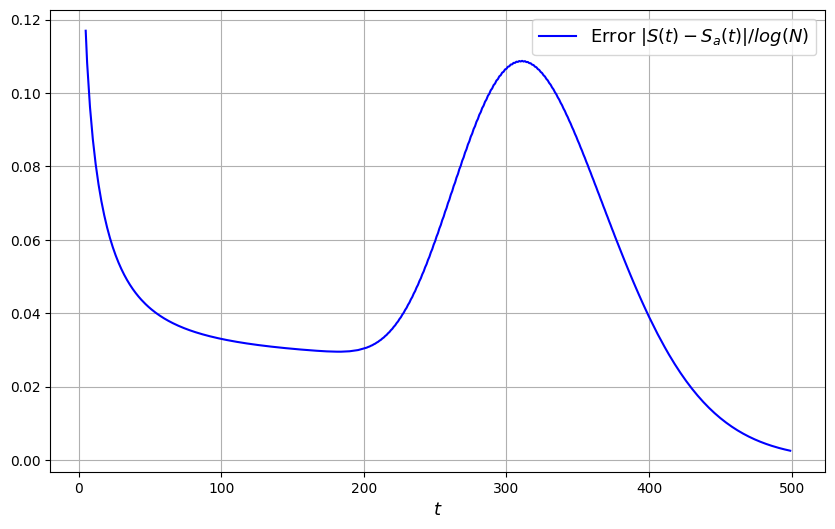

In [24]:
#plot of error with respect to log(N)
error = []
t_values = []
N = 100
for t in range(5, tmax):
    S_exact = S_entropy(N, omega, t)
    S_analytic = S_corrected(N, omega, t)
    error.append(abs(S_exact - S_analytic)/np.log(N))
    t_values.append(t)
plt.figure(figsize=(10, 6))
plt.plot(t_values, error, color = 'blue', label = 'Error $|S(t) - S_{a}(t)|/log(N)$')
plt.grid(True)
plt.xlabel(r'$t$', fontsize=13)
plt.legend(fontsize=13)
plt.savefig("error_oqw_entropy.pgf")
plt.show()

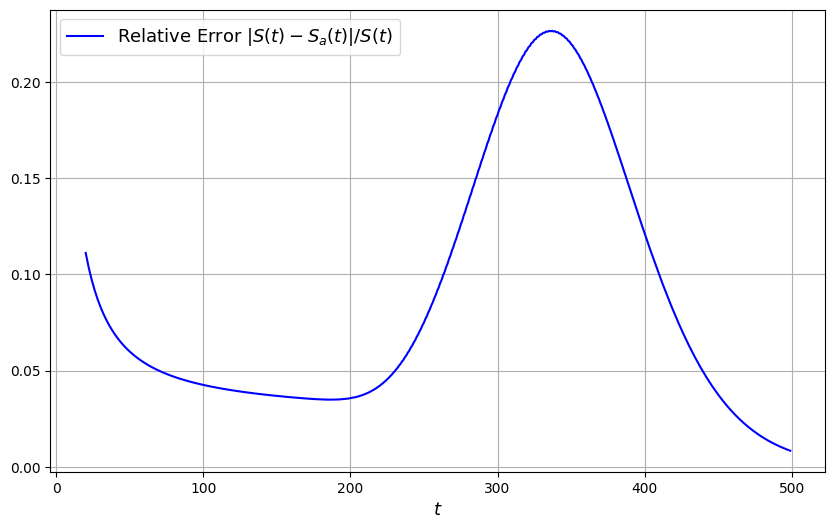

In [27]:
#relative error plot
error = []
t_values = []
N = 100
for t in range(20, tmax):
    S_exact = S_entropy(N, omega, t)
    S_analytic = S_corrected(N, omega, t)
    error.append(abs(S_exact - S_analytic)/S_exact)
    t_values.append(t)
plt.figure(figsize=(10, 6))
plt.plot(t_values, error, color = 'blue', label = 'Relative Error $|S(t) - S_{a}(t)|/S(t)$')
plt.grid(True)
plt.xlabel(r'$t$', fontsize=13)
plt.legend(fontsize=13)
plt.savefig("relative_error_oqw_entropy.pgf")
plt.show()

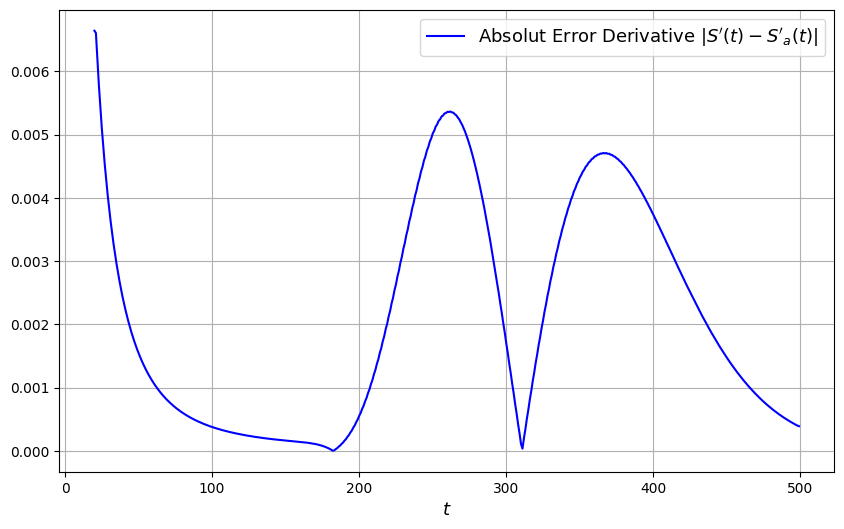

In [35]:
#absolute error of derivative of entropies plot using np gradient
t_values = []
S_exact_list = []
S_analytic_list = []

N = 100
for t in range(20, tmax):
    S_exact = S_entropy(N, omega, t)
    S_analytic = S_corrected(N, omega, t)
    S_exact_list.append(S_exact)
    S_analytic_list.append(S_analytic)
    t_values.append(t)

S_exact_derivative = np.gradient(S_exact_list, t_values)
S_analytic_derivative = np.gradient(S_analytic_list, t_values)
absolut_error_derivative = abs(S_exact_derivative - S_analytic_derivative)
plt.figure(figsize=(10, 6))
plt.plot(t_values, absolut_error_derivative, color = 'blue', label = 'Absolut Error Derivative $|S\'(t) - S\'_{a}(t)|$')
plt.grid(True)
plt.xlabel(r'$t$', fontsize=13)
plt.legend(fontsize=13)
plt.savefig("absolut_error_derivative_oqw_entropy.pgf")
plt.show()

In [ ]:
#average relative error between zero and t_end
t_values = []
S_exact_list = []
N = 500
omega = 2/3
for t in range(0, math.ceil(t_end(N,omega)+1)):
    S_exact = S_entropy(N, omega, t)
    S_exact_list.append(S_exact)
    t_values.append(t)
average_relative_error = sum([abs(S_exact_list[t] - S_corrected(N,omega,t))/S_exact_list[t] for t in range(5,len(t_values))]) / len(t_values)
average_absolute_error = sum([abs(S_exact_list[t] - S_corrected(N,omega,t)) for t in range(5,len(t_values))]) / len(t_values)
maximum_relative_error = max([abs(S_exact_list[t] - S_corrected(N,omega,t))/S_exact_list[t] for t in range(5,len(t_values))])
maximum_absolute_error = max([abs(S_exact_list[t] - S_corrected(N,omega,t)) for t in range(5,len(t_values))])
print("Average relative error between 0 and t_end:", average_relative_error)
print("Maximum relative error between 0 and t_end:", maximum_relative_error)
print("Maximum absolute error between 0 and t_end:", maximum_absolute_error)
print("Average scaled error between 0 and t_end:", average_absolute_error/np.log(N))
print("Maximum scaled error between 0 and t_end:", maximum_absolute_error/np.log(N))

In [58]:
#average relative error between t_start and t_end
N = 500
omega = 2/3

error = []
scaled_error =  []
for t in range(math.ceil(t_start(N,omega)), math.ceil(t_end(N,omega)+1)):
    S_exact = S_entropy(N, omega, t)
    S_analytic = S_corrected(N, omega, t)
    error.append(abs(S_exact - S_analytic)/S_exact)
    scaled_error.append(abs(S_exact - S_analytic)/np.log(N))
average_relative_error = sum(error) / len(error)
print("Average relative error between t_start and t_end:", average_relative_error)
scaled_relative_error = sum(scaled_error) / len(scaled_error)
print("Average scaled error between t_start and t_end:", scaled_relative_error)

Average relative error between t_start and t_end: 0.08336015113809603
Average scaled error between t_start and t_end: 0.03560720839620245


In [59]:
#maximum relative error between zero and t_end
N = 500
omega = 2/3

t_values = []
for t in range(0, math.ceil(t_end(N,omega)+1)):
    t_values.append(t)
relative_errors = [abs(S_entropy(N, omega, t) - S_corrected(N,omega,t))/S_entropy(N, omega, t) for t in range(5,len(t_values))]
max_relative_error = max(relative_errors)
print("Maximum relative error between 0 and t_end:", max_relative_error)

Maximum relative error between 0 and t_end: 0.3196456568789911


In [60]:
#maximum absolute error between zero and t_end
N = 500
omega = 2/3

t_values = []
for t in range(0, math.ceil(t_end(N,omega)+1)):
    t_values.append(t)
absolute_errors = [abs(S_entropy(N, omega, t) - S_corrected(N,omega,t)) for t in range(5,len(t_values))]
max_absolute_error = max(absolute_errors)
print("Maximum absolute error between 0 and t_end:", max_absolute_error)
print("Maximum scaled error between 0 and t_end:", max_absolute_error/np.log(N))

Maximum absolute error between 0 and t_end: 0.5386161468231712
Maximum scaled error between 0 and t_end: 0.0866693664818412
